In [1]:
import pandas as pd

In [2]:
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes",
"land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
"num_compromised","root_shell","su_attempted","num_root","num_file_creations",
"num_shells","num_access_files","num_outbound_cmds","is_host_login",
"is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
"rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
"srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

df_train = pd.read_csv("../data/raw/nsl-kdd/KDDTrain+.txt", names=columns)
df_test  = pd.read_csv("../data/raw/nsl-kdd/KDDTest+.txt", names=columns)

df_train.shape

(125973, 43)

In [3]:
df_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
df_train.dtypes

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [5]:
df_train["label"].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

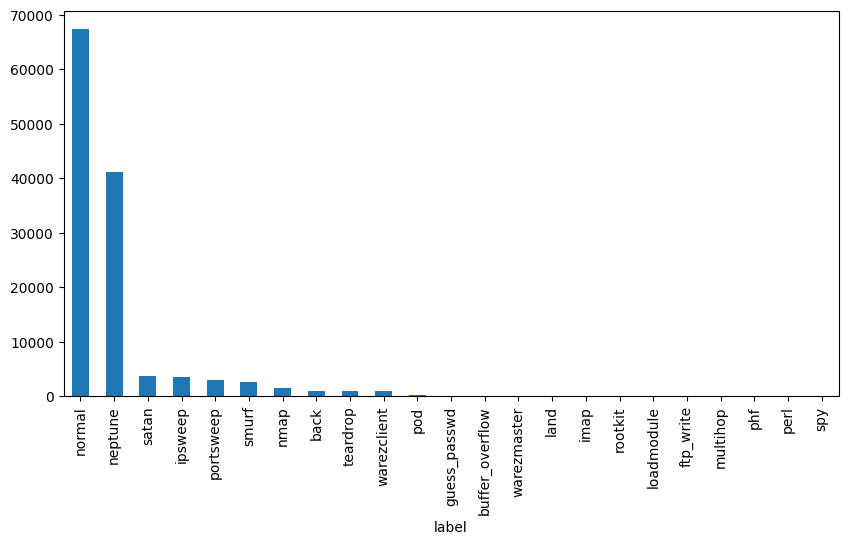

In [6]:
import matplotlib.pyplot as plt

df_train["label"].value_counts().plot(kind="bar", figsize=(10,5))
plt.show()

In [7]:
df_train = df_train.drop_duplicates()
df_test = df_test.drop_duplicates()

df_train = df_train.drop(columns=["difficulty"])
df_test = df_test.drop(columns=["difficulty"])

In [8]:
df_train["binary_label"] = df_train["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)

In [9]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ["protocol_type", "service", "flag"]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])
    encoders[col] = le

In [13]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = df_train.select_dtypes(include=["int64","float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in categorical_cols]

scaler = MinMaxScaler()
df_train[numeric_cols] = scaler.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = scaler.transform(df_test[numeric_cols])

In [14]:
import os
import joblib

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../ml/preprocessing/artifacts", exist_ok=True)

df_train.to_csv("../data/processed/train.csv", index=False)
df_test.to_csv("../data/processed/test.csv", index=False)

joblib.dump(scaler, "../ml/preprocessing/artifacts/scaler.pkl")
joblib.dump(encoders, "../ml/preprocessing/artifacts/encoders.pkl")

['../ml/preprocessing/artifacts/encoders.pkl']